# 🧬 Cheminformatics for Drug Discovery
### A Practical Notebook

---

**Author:** Jane Anebi and Festus Ogungbemiro  
**Date:** May, 2026  
**Tools:** RDKit, numpy, pandas, matplotlib, seaborn, py3Dmol, sklearn

---

## Overview

This notebook covers foundational concepts in cheminformatics workflows relevant to early-stage drug discovery, **without requiring any machine learning**. The topics covered include:

1. **Molecular Representation** — SMILES, InChI, and molecular graphs  
2. **Molecular Descriptors & Fingerprints** — physicochemical properties, Morgan fingerprints  
3. **Lipinski's Rule of Five & Drug-likeness Filters** — ADMET screening  
4. **Chemical Similarity & Diversity Analysis** — Tanimoto coefficient, scaffold diversity  
5. **Virtual Screening of a Compound Library** — filtering hits from a dataset  
6. **Scaffold Analysis & Bemis-Murcko Decomposition** — scaffold frequency mapping  
7. **PAINS Filtering** — removing pan-assay interference compounds  
8. **Molecular Visualization** — 2D structure grids and 3D rendering  
9. **Chemical Space Visualization** — PCA-based chemical space mapping  

---

## ⚙️ Installation Requirements

Run the following cell once before anything else. Open **Anaconda Prompt** or your terminal and execute:

```bash
conda install -c conda-forge rdkit -y
pip install pandas matplotlib seaborn py3Dmol scikit-learn ipywidgets
```

Or install everything in one step using the cell below.


In [1]:
# ============================================================
# CELL 0 — Environment Check
# ============================================================
# This notebook assumes you have already created the project environment
# using EITHER conda (environment.yml) OR pip (requirements.txt), as
# described in README.md. Do not mix conda and pip installs in the same
# environment - pick one route and follow it exactly once, then launch
# Jupyter from that environment.
#
#   Conda route:  conda env create -f environment.yml
#   Pip route:    python -m venv .venv && source .venv/bin/activate
#                 pip install -r requirements.txt
#
# The check below only VALIDATES that the key packages are importable and
# reports their versions - it does not install anything.

import importlib
import sys

required = ["rdkit", "pandas", "numpy", "matplotlib", "seaborn", "sklearn"]
missing = []
for pkg in required:
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, "__version__", "unknown")
        print(f"✅ {pkg:12s} {version}")
    except ImportError:
        missing.append(pkg)
        print(f"❌ {pkg:12s} NOT FOUND")

if missing:
    print(
        f"\nMissing packages: {missing}. "
        "Please create the environment from environment.yml or requirements.txt "
        "(see README.md) and restart the kernel before continuing."
    )
else:
    print(f"\nPython {sys.version.split()[0]} - all required packages found. Ready to proceed.")


✅ rdkit        2026.03.4
✅ pandas       3.0.3
✅ numpy        1.26.4
✅ matplotlib   3.11.0
✅ seaborn      0.13.2
✅ sklearn      1.9.0

Python 3.11.15 - all required packages found. Ready to proceed.


---

## Section 1 — Importing Libraries and Dataset Setup

We begin by importing all required libraries and defining a curated dataset of known bioactive molecules — including approved drugs and clinical candidates — represented as **SMILES strings** (Simplified Molecular Input Line Entry System), the standard text-based molecular notation in cheminformatics.

The dataset includes molecules spanning multiple therapeutic classes (antibiotics, antivirals, kinase inhibitors, etc.), which provides good chemical diversity for our analyses.


In [2]:
# ============================================================
# CELL 1 — Library imports and dataset definition
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# RDKit — cheminformatics engine
from rdkit import Chem, DataStructs
from rdkit.Chem import (
    Draw, Descriptors, AllChem, rdMolDescriptors,
    FilterCatalog, rdFMCS, Scaffolds
)
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # suppress RDKit warnings

# PCA for chemical space
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# IPython display
from IPython.display import display, Image, HTML
from io import BytesIO
from PIL import Image as PILImage

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries imported successfully.")

# -------------------------------------------------------
# Curated dataset: Name, SMILES, therapeutic class, target
# -------------------------------------------------------
DATA = [
    # Kinase inhibitors
    {"name": "Imatinib",        "smiles": "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1",          "class": "Kinase Inhibitor",   "target": "BCR-ABL"},
    {"name": "Erlotinib",       "smiles": "C#Cc1cccc(Nc2ncnc3cc(OCC)c(OCC)cc23)c1",                               "class": "Kinase Inhibitor",   "target": "EGFR"},
    {"name": "Gefitinib",       "smiles": "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1",                      "class": "Kinase Inhibitor",   "target": "EGFR"},
    {"name": "Sorafenib",       "smiles": "CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1",          "class": "Kinase Inhibitor",   "target": "RAF/VEGFR"},
    {"name": "Sunitinib",       "smiles": "CCN(CC)CCNC(=O)c1c(C)[nH]c(\\C=C/2C(=O)Nc3ccc(F)cc32)c1C",           "class": "Kinase Inhibitor",   "target": "VEGFR"},
    {"name": "Lapatinib",       "smiles": "CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1","class": "Kinase Inhibitor",   "target": "HER2/EGFR"},
    # Protease inhibitors
    {"name": "Ritonavir",       "smiles": "CC(C)c1nc(CN(C)C(=O)Nc2ccc(C(C)(C)C)cc2)cs1",                         "class": "Protease Inhibitor", "target": "HIV Protease"},
    {"name": "Lopinavir",       "smiles": "CC1(C)OC2CC(O)(CC2O1)C(=O)NC(Cc1ccc(N)cc1)C(=O)NC(CC(C)C)CC(O)C(Cc1ccccc1)NC(=O)c1ccc2c(c1)CCCN2C", "class": "Protease Inhibitor", "target": "HIV Protease"},
    {"name": "Indinavir",       "smiles": "OC(CO)(Cc1ccccc1)CC(O)C(Cc1ccccc1)NC(=O)C1CC2CCCC(C2)N1Cc1cccnc1",  "class": "Protease Inhibitor", "target": "HIV Protease"},
    # Antibiotics
    {"name": "Ciprofloxacin",   "smiles": "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",                         "class": "Antibiotic",         "target": "DNA Gyrase"},
    {"name": "Amoxicillin",     "smiles": "CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O",                  "class": "Antibiotic",         "target": "PBP"},
    {"name": "Levofloxacin",    "smiles": "C[C@@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23",             "class": "Antibiotic",         "target": "DNA Gyrase"},
    {"name": "Tetracycline",    "smiles": "CN(C)C1C2CC3C(=C(O)c4c(O)cccc4C3=O)C(=O)C2C(O)=C(C(N)=O)C1=O",     "class": "Antibiotic",         "target": "Ribosome"},
    # Antivirals
    {"name": "Oseltamivir",     "smiles": "CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@@H](NC(C)=O)[C@@H](N)C1",            "class": "Antiviral",          "target": "Neuraminidase"},
    {"name": "Remdesivir",      "smiles": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@@H]1[C@H]([C@H]([C@](O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4", "class": "Antiviral",         "target": "RdRp"},
    {"name": "Acyclovir",       "smiles": "Nc1nc2c(ncn2COCCO)c(=O)[nH]1",                                        "class": "Antiviral",          "target": "Viral TK"},
    # CNS drugs
    {"name": "Donepezil",       "smiles": "COc1cc2c(cc1OC)CC(CC1CCN(Cc3ccccc3)CC1)C2",                          "class": "CNS",                "target": "AChE"},
    {"name": "Sertraline",      "smiles": "ClC1=CC=C([C@@H]2[C@@H](CNC)CCCC2)C(Cl)=C1",                         "class": "CNS",                "target": "SERT"},
    {"name": "Clozapine",       "smiles": "CN1CCN(c2nc3ccccc3nc2Cl)CC1",                                         "class": "CNS",                "target": "D4/5-HT2"},
    # Cardiovascular
    {"name": "Atorvastatin",    "smiles": "CC(C)c1c(-c2ccc(F)cc2)c(-c2ccccc2)c2c(n1)CC(O)C[C@@H]2O",           "class": "Cardiovascular",     "target": "HMG-CoA reductase"},
    {"name": "Amlodipine",      "smiles": "CCOC(=O)C1=C(COCCN)NC(C)=C(C(=O)OC)C1c1ccccc1Cl",                  "class": "Cardiovascular",     "target": "Calcium channel"},
    {"name": "Metoprolol",      "smiles": "CC(C)NCC(O)COc1ccc(CCOC)cc1",                                        "class": "Cardiovascular",     "target": "β1-adrenoreceptor"},
    # GPCR ligands
    {"name": "Albuterol",       "smiles": "CC(C)(C)NCC(O)c1ccc(O)c(CO)c1",                                      "class": "GPCR Ligand",        "target": "β2-adrenoreceptor"},
    {"name": "Morphine",        "smiles": "OC1=CC=C2C[C@H]3N(C)CC[C@@]45[C@@H]3Oc1c2[C@]4(O)CC[C@H]5O",       "class": "GPCR Ligand",        "target": "μ-opioid receptor"},
    # Decoys / non-druglike (for filtering demo)
    {"name": "Decoy_1",         "smiles": "CCCCCCCCCCCCCCCCCCCC",                                                "class": "Decoy",              "target": "None"},
    {"name": "Decoy_2",         "smiles": "CC(=O)OCC(=O)OCC(=O)OCC(=O)O",                                       "class": "Decoy",              "target": "None"},
    {"name": "Decoy_3",         "smiles": "NCCCCCCCCCCCCCCN",                                                    "class": "Decoy",              "target": "None"},
    {"name": "Decoy_4",         "smiles": "Oc1ccc(O)c(O)c1O",                                                   "class": "Decoy",              "target": "None"},
]

df = pd.DataFrame(DATA)
print(f"✅ Dataset loaded: {len(df)} compounds across {df['class'].nunique()} therapeutic classes.")
df.head(20)

✅ All libraries imported successfully.
✅ Dataset loaded: 28 compounds across 8 therapeutic classes.


,name,smiles,class,target
0,Imatinib,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...,Kinase Inhibitor,BCR-ABL
1,Erlotinib,C#Cc1cccc(Nc2ncnc3cc(OCC)c(OCC)cc23)c1,Kinase Inhibitor,EGFR
2,Gefitinib,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,Kinase Inhibitor,EGFR
3,Sorafenib,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,Kinase Inhibitor,RAF/VEGFR
4,Sunitinib,CCN(CC)CCNC(=O)c1c(C)[nH]c(\C=C/2C(=O)Nc3ccc(F...,Kinase Inhibitor,VEGFR
5,Lapatinib,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5ccc...,Kinase Inhibitor,HER2/EGFR
6,Ritonavir,CC(C)c1nc(CN(C)C(=O)Nc2ccc(C(C)(C)C)cc2)cs1,Protease Inhibitor,HIV Protease
7,Lopinavir,CC1(C)OC2CC(O)(CC2O1)C(=O)NC(Cc1ccc(N)cc1)C(=O...,Protease Inhibitor,HIV Protease
8,Indinavir,OC(CO)(Cc1ccccc1)CC(O)C(Cc1ccccc1)NC(=O)C1CC2C...,Protease Inhibitor,HIV Protease
9,Ciprofloxacin,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,Antibiotic,DNA Gyrase


---

## Section 2 — Molecular Representation: SMILES → RDKit Mol Objects

Before any computation, each SMILES string must be **parsed into an RDKit Mol object** — a graph-based representation that encodes atoms, bonds, stereochemistry, and aromaticity. Invalid SMILES are flagged and removed. This step is critical in any real drug discovery pipeline where input data quality varies.

We also compute the **InChI** (International Chemical Identifier) and **InChIKey** for each molecule — standardized identifiers commonly used in databases such as PubChem and ChEMBL for unambiguous compound lookup.


In [3]:
# ============================================================
# CELL 2 — Parse SMILES and generate InChI identifiers
# ============================================================

from rdkit.Chem.inchi import MolToInchi, InchiToInchiKey

def parse_smiles(smiles):
    """Convert SMILES to an RDKit Mol; return None if invalid."""
    mol = Chem.MolFromSmiles(smiles)
    return mol

df['mol'] = df['smiles'].apply(parse_smiles)

# Flag and report invalid SMILES
invalid = df[df['mol'].isnull()]
if len(invalid) > 0:
    print(f"⚠️  {len(invalid)} invalid SMILES removed: {invalid['name'].tolist()}")
    df = df[df['mol'].notnull()].reset_index(drop=True)
else:
    print("✅ All SMILES parsed successfully.")

# Generate InChI and InChIKey for each molecule
def safe_inchi(mol):
    try:
        return MolToInchi(mol)
    except:
        return None

def safe_inchikey(inchi):
    try:
        return InchiToInchiKey(inchi) if inchi else None
    except:
        return None

df['inchi']    = df['mol'].apply(safe_inchi)
df['inchikey'] = df['inchi'].apply(safe_inchikey)

# Canonicalize SMILES using RDKit
df['canonical_smiles'] = df['mol'].apply(lambda m: Chem.MolToSmiles(m))

print(f"\nMolecular identifiers generated for {len(df)} compounds.")
df[['name', 'canonical_smiles', 'inchikey']].head(8)

✅ All SMILES parsed successfully.

Molecular identifiers generated for 28 compounds.


,name,canonical_smiles,inchikey
0,Imatinib,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...,KTUFNOKKBVMGRW-UHFFFAOYSA-N
1,Erlotinib,C#Cc1cccc(Nc2ncnc3cc(OCC)c(OCC)cc23)c1,CBKURHQKZANARB-UHFFFAOYSA-N
2,Gefitinib,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,XGALLCVXEZPNRQ-UHFFFAOYSA-N
3,Sorafenib,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,MLDQJTXFUGDVEO-UHFFFAOYSA-N
4,Sunitinib,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2/C(=O)Nc3ccc(F...,WINHZLLDWRZWRT-SFQUDFHCSA-N
5,Lapatinib,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5ccc...,BCFGMOOMADDAQU-UHFFFAOYSA-N
6,Ritonavir,CC(C)c1nc(CN(C)C(=O)Nc2ccc(C(C)(C)C)cc2)cs1,UVVWONYEAREUGF-UHFFFAOYSA-N
7,Lopinavir,CC(C)CC(CC(O)C(Cc1ccccc1)NC(=O)c1ccc2c(c1)CCCN...,RLMAJIBBOMUCFX-UHFFFAOYSA-N


---

## Section 3 — Physicochemical Descriptor Calculation

Molecular descriptors quantify the structural and physicochemical properties of compounds. They are central to **ADMET prediction** (Absorption, Distribution, Metabolism, Excretion, Toxicity) and **drug-likeness assessment**.

Here we calculate a comprehensive set of descriptors for each compound:

| Descriptor | Symbol | Relevance |
|---|---|---|
| Molecular Weight | MW | Absorption / membrane permeability |
| LogP (Wildman-Crippen) | cLogP | Lipophilicity, membrane partitioning |
| H-bond donors | HBD | Oral bioavailability |
| H-bond acceptors | HBA | Oral bioavailability |
| Topological Polar Surface Area | TPSA | GI absorption, CNS penetration |
| Rotatable bonds | RotBonds | Molecular flexibility / oral bioavailability |
| Molar Refractivity | MR | Molecular volume proxy |
| Fraction sp3 carbons | Fsp3 | Drug-likeness / 3D character |
| Formal charge | Charge | Permeability |
| Number of rings | Rings | Scaffold complexity |


In [4]:
# ============================================================
# CELL 3 — Compute physicochemical descriptors
# ============================================================

def compute_descriptors(mol):
    """Return a dict of key physicochemical descriptors for a molecule."""
    if mol is None:
        return {}
    return {
        'MW':        round(Descriptors.MolWt(mol), 2),
        'cLogP':     round(Descriptors.MolLogP(mol), 3),
        'HBD':       rdMolDescriptors.CalcNumHBD(mol),
        'HBA':       rdMolDescriptors.CalcNumHBA(mol),
        'TPSA':      round(Descriptors.TPSA(mol), 2),
        'RotBonds':  rdMolDescriptors.CalcNumRotatableBonds(mol),
        'MR':        round(Descriptors.MolMR(mol), 2),
        'Fsp3':      round(rdMolDescriptors.CalcFractionCSP3(mol), 3),
        'Charge':    Chem.GetFormalCharge(mol),
        'Rings':     rdMolDescriptors.CalcNumRings(mol),
        'ArRings':   rdMolDescriptors.CalcNumAromaticRings(mol),
        'HeavyAtoms': mol.GetNumHeavyAtoms(),
    }

desc_df = df['mol'].apply(compute_descriptors).apply(pd.Series)
df = pd.concat([df, desc_df], axis=1)

print("✅ Descriptors computed for all compounds.\n")
desc_cols = ['name', 'class', 'MW', 'cLogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Fsp3', 'Rings']
df[desc_cols].sort_values('MW').to_csv('descriptors_table.csv', index=False)
print("📄 Table saved to: descriptors_table.csv")
df[desc_cols]

✅ Descriptors computed for all compounds.

📄 Table saved to: descriptors_table.csv


,name,class,MW,cLogP,HBD,HBA,TPSA,RotBonds,Fsp3,Rings
0,Imatinib,Kinase Inhibitor,493.62,4.590,2.0,7.0,86.28,7.0,0.241,5.0
1,Erlotinib,Kinase Inhibitor,333.39,4.152,1.0,5.0,56.27,6.0,0.200,3.0
2,Gefitinib,Kinase Inhibitor,446.91,4.276,1.0,7.0,68.74,8.0,0.364,4.0
3,Sorafenib,Kinase Inhibitor,464.83,5.550,3.0,4.0,92.35,5.0,0.095,3.0
4,Sunitinib,Kinase Inhibitor,398.48,3.335,3.0,3.0,77.23,7.0,0.364,3.0
5,Lapatinib,Kinase Inhibitor,581.07,6.139,2.0,8.0,106.35,11.0,0.172,5.0
6,Ritonavir,Protease Inhibitor,345.51,5.228,1.0,3.0,45.23,4.0,0.474,2.0
7,Lopinavir,Protease Inhibitor,769.98,4.047,6.0,9.0,175.48,15.0,0.523,6.0
8,Indinavir,Protease Inhibitor,557.74,3.659,4.0,6.0,105.92,12.0,0.471,5.0
9,Ciprofloxacin,Antibiotic,331.35,1.583,2.0,4.0,74.57,3.0,0.412,4.0


---

## Section 4 — Lipinski's Rule of Five & Extended Drug-likeness Filters

**Lipinski's Rule of Five (Ro5)**, proposed by Christopher Lipinski at Pfizer in 1997, remains the most widely used heuristic for predicting oral bioavailability. A molecule is considered drug-like if it satisfies *most* of the following:

- **MW ≤ 500 Da** — small enough for intestinal absorption  
- **cLogP ≤ 5** — not too lipophilic  
- **HBD ≤ 5** — few hydrogen-bond donors  
- **HBA ≤ 10** — not too many hydrogen-bond acceptors  

**Why apply three filters instead of one?** Each filter reflects a different stage of a real drug-discovery funnel. Early hit identification uses the permissive Ro5/Veber boundaries to avoid discarding viable chemotypes; as compounds move toward a focused optimization campaign, tighter lead-likeness thresholds are applied because subsequent medicinal chemistry (adding substituents, rings, or heteroatoms) tends to *increase* MW and cLogP — so a "lead" needs headroom below the final Ro5 ceiling. This is why we score every compound in this notebook against all three tiers rather than a single cutoff: it lets you see how the same 28-compound set shrinks as the funnel narrows, and why a compound can be a perfectly good drug (e.g. Lopinavir, MW 770 Da) while failing to look "lead-like" at all.

We also apply two additional widely-used filters:

- **Veber's Rules** (oral bioavailability in rats): TPSA ≤ 140 Å² AND RotBonds ≤ 10  
- **Lead-likeness (Oprea)**: MW ≤ 460, cLogP ≤ 4.2, HBD ≤ 5, HBA ≤ 9, RotBonds ≤ 10  


Drug-likeness Filter Summary
                Filter  Pass  Fail  Pass%
          Lipinski Ro5    25     3   89.3
         Veber's Rules    21     7   75.0
         Lead-likeness    15    13   53.6
Ro5 + Veber (combined)    21     7   75.0


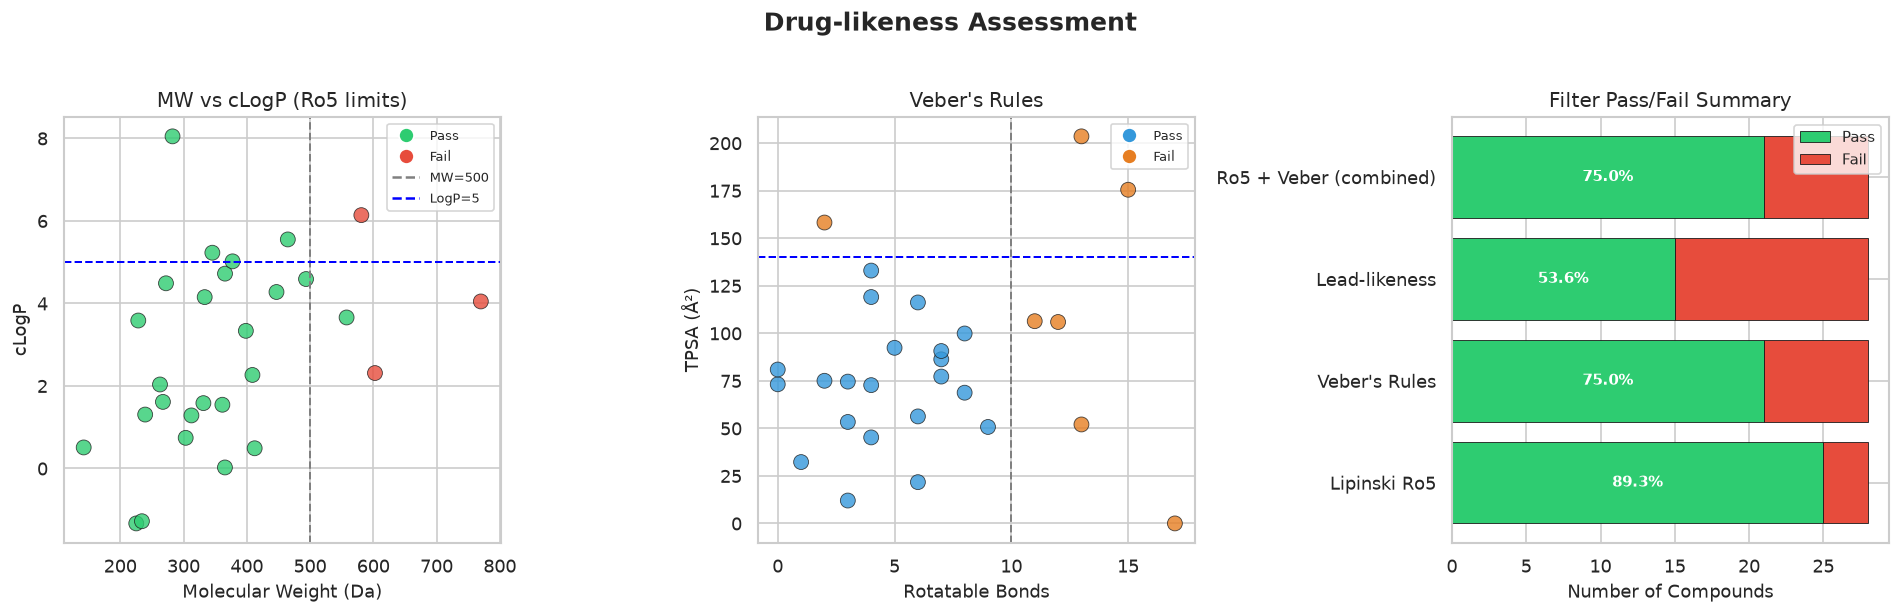


📊 Figure saved to: drug_likeness_filters.png


In [5]:
# ============================================================
# CELL 4 — Apply drug-likeness filters and visualize results
# ============================================================

def lipinski_ro5(row):
    """Returns True if molecule passes Lipinski's Rule of Five."""
    violations = sum([
        row['MW']   > 500,
        row['cLogP'] > 5,
        row['HBD']  > 5,
        row['HBA']  > 10,
    ])
    return violations <= 1  # Allow 1 violation (original Lipinski rule)

def veber_rules(row):
    """Returns True if molecule satisfies Veber's oral bioavailability criteria."""
    return (row['TPSA'] <= 140) and (row['RotBonds'] <= 10)

def lead_like(row):
    """Returns True if molecule satisfies lead-likeness criteria (Oprea)."""
    return (
        row['MW']       <= 460 and
        row['cLogP']    <= 4.2 and
        row['HBD']      <= 5   and
        row['HBA']      <= 9   and
        row['RotBonds'] <= 10
    )

df['Ro5_pass']      = df.apply(lipinski_ro5, axis=1)
df['Veber_pass']    = df.apply(veber_rules, axis=1)
df['LeadLike_pass'] = df.apply(lead_like,  axis=1)
df['All_pass']      = df['Ro5_pass'] & df['Veber_pass']

# ---- Summary table ----
filter_summary = pd.DataFrame({
    'Filter':   ['Lipinski Ro5', "Veber's Rules", 'Lead-likeness', 'Ro5 + Veber (combined)'],
    'Pass':     [df['Ro5_pass'].sum(), df['Veber_pass'].sum(),
                 df['LeadLike_pass'].sum(), df['All_pass'].sum()],
    'Fail':     [len(df)-df['Ro5_pass'].sum(), len(df)-df['Veber_pass'].sum(),
                 len(df)-df['LeadLike_pass'].sum(), len(df)-df['All_pass'].sum()],
})
filter_summary['Pass%'] = (filter_summary['Pass'] / len(df) * 100).round(1)
print("Drug-likeness Filter Summary")
print("=" * 45)
print(filter_summary.to_string(index=False))

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Drug-likeness Assessment", fontsize=15, fontweight='bold', y=1.02)

# Plot 1: MW vs cLogP with Ro5 boundary
ax = axes[0]
colors = df['Ro5_pass'].map({True: '#2ecc71', False: '#e74c3c'})
ax.scatter(df['MW'], df['cLogP'], c=colors, s=80, alpha=0.8, edgecolors='k', linewidth=0.5)
ax.axvline(500, color='gray', linestyle='--', linewidth=1.2, label='MW=500')
ax.axhline(5,   color='blue', linestyle='--', linewidth=1.2, label='LogP=5')
ax.set_xlabel('Molecular Weight (Da)', fontsize=11)
ax.set_ylabel('cLogP', fontsize=11)
ax.set_title("MW vs cLogP (Ro5 limits)", fontsize=12)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=9, label='Pass'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=9, label='Fail'),
]
ax.legend(handles=legend_handles + [
    Line2D([0],[0], color='gray', linestyle='--', label='MW=500'),
    Line2D([0],[0], color='blue', linestyle='--', label='LogP=5'),
], fontsize=8)

# Plot 2: TPSA vs RotBonds (Veber)
ax = axes[1]
colors2 = df['Veber_pass'].map({True: '#3498db', False: '#e67e22'})
ax.scatter(df['RotBonds'], df['TPSA'], c=colors2, s=80, alpha=0.8, edgecolors='k', linewidth=0.5)
ax.axvline(10,  color='gray', linestyle='--', linewidth=1.2)
ax.axhline(140, color='blue', linestyle='--', linewidth=1.2)
ax.set_xlabel('Rotatable Bonds', fontsize=11)
ax.set_ylabel('TPSA (Å²)', fontsize=11)
ax.set_title("Veber's Rules", fontsize=12)
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3498db', markersize=9, label='Pass'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e67e22', markersize=9, label='Fail'),
], fontsize=8)

# Plot 3: Stacked bar of filter outcomes
ax = axes[2]
x = filter_summary['Filter']
ax.barh(x, filter_summary['Pass'],  color='#2ecc71', label='Pass', edgecolor='k', linewidth=0.5)
ax.barh(x, filter_summary['Fail'],  left=filter_summary['Pass'],
        color='#e74c3c', label='Fail', edgecolor='k', linewidth=0.5)
ax.set_xlabel('Number of Compounds', fontsize=11)
ax.set_title('Filter Pass/Fail Summary', fontsize=12)
ax.legend(fontsize=9)
for i, (p, pct) in enumerate(zip(filter_summary['Pass'], filter_summary['Pass%'])):
    ax.text(p/2, i, f'{pct}%', va='center', ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('drug_likeness_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Figure saved to: drug_likeness_filters.png")

**Interpreting the results above.** Of the 28 compounds, 89.3% pass Lipinski's Ro5, 75.0% pass Veber's rules, and only 53.6% qualify as lead-like — a progressively shrinking pass rate that mirrors the narrowing drug-discovery funnel described above, not a flaw in the dataset.

The three Ro5 failures are deliberately included and are well-documented, clinically meaningful exceptions rather than filter errors:
- **Lopinavir** (MW 769.98 Da) is co-formulated with ritonavir, a pharmacokinetic booster that inhibits its first-pass metabolism, allowing an otherwise oversized molecule to reach therapeutic plasma levels orally.
- **Lapatinib** (MW 581.07 Da, cLogP 6.14) achieves adequate exposure through high oral dosing rather than passive-permeability-optimized design.
- **Remdesivir** (HBA 12) is dosed intravenously as a prodrug, so oral absorption — the property Ro5 was built to predict — is not a relevant design constraint for it at all.

The pedagogical takeaway: **Ro5/Veber/lead-likeness are statistical heuristics describing a historical population of oral drugs, not physical laws.** Always ask *how* a compound reaches the patient (oral vs IV, actively transported vs passively absorbed, prodrug vs parent) before treating a filter failure as disqualifying — and, symmetrically, don't assume a filter "pass" guarantees good pharmacokinetics. In a real screening campaign you would run this same analysis on a much larger, less curated library (e.g. a vendor catalog or ZINC subset), where filter attrition is typically far more aggressive than in this illustrative 28-compound set.


---

## Section 5 — Molecular Fingerprints & Chemical Similarity

**Molecular fingerprints** are binary or count vectors encoding the presence or absence of structural features. They are the backbone of ligand-based drug discovery for:

- **Similarity searching** — finding analogs of an active compound  
- **Scaffold hopping** — identifying structurally diverse actives  
- **Diversity selection** — building a representative screening library  

We use **Morgan fingerprints** (circular fingerprints based on the Morgan algorithm, equivalent to ECFP4), which capture extended connectivity environments around each atom. Similarity is measured by the **Tanimoto coefficient** (Jaccard index for binary vectors), ranging from 0 (no similarity) to 1 (identical).

$$T(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

A commonly used threshold: **Tc ≥ 0.40** is considered bioisosteric similarity, **Tc ≥ 0.85** indicates near-identical structures.

**A caution on this threshold:** these values are typical defaults for Morgan/ECFP-type fingerprints specifically, not a universal constant. Switching to a different fingerprint (e.g. MACCS keys, topological/RDKit fingerprints, or a pharmacophore-based fingerprint) changes what fraction of bits is shared between any two molecules, so the same two compounds can show a very different Tc under a different fingerprint choice. Treat Tc thresholds as fingerprint-specific rules of thumb to be recalibrated for your own dataset and fingerprint, not as fixed cutoffs.


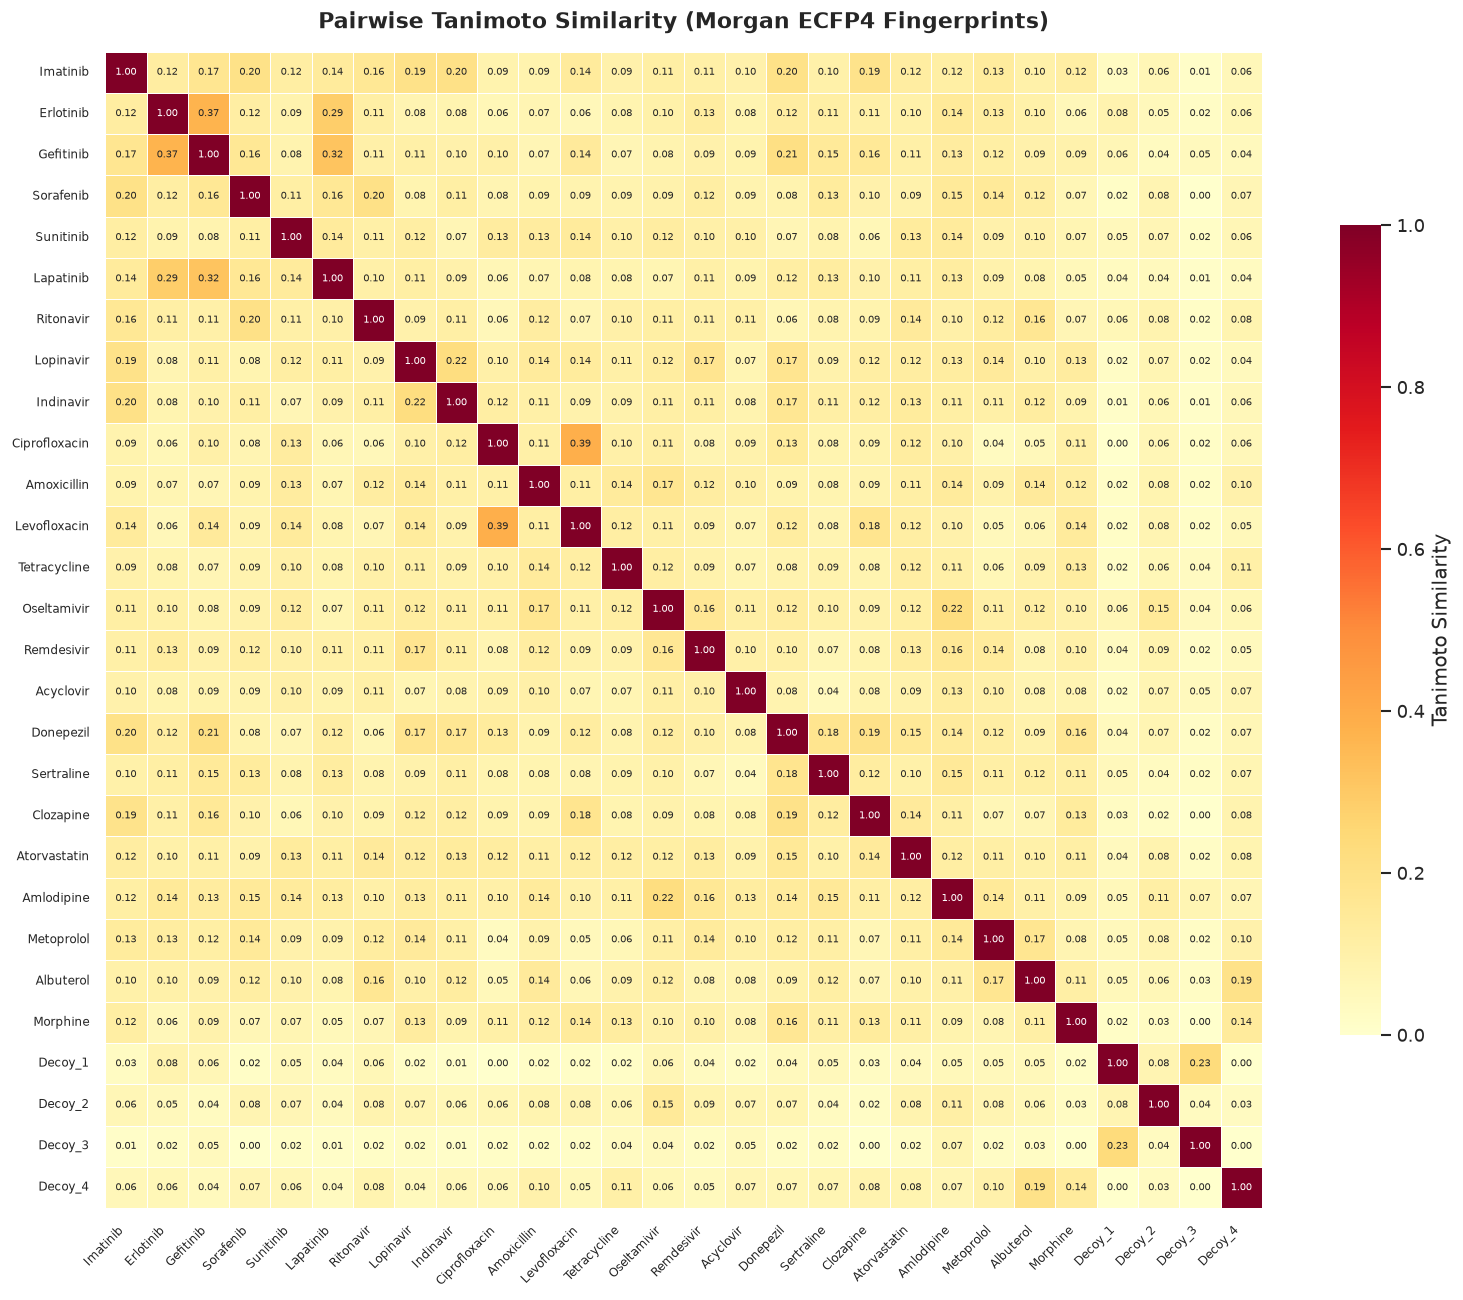

📊 Saved: tanimoto_heatmap.png

🔍 Top 5 Most Similar Compound Pairs (Tc ≥ threshold):
   Compound_A   Compound_B  Tanimoto
Ciprofloxacin Levofloxacin    0.3857
    Erlotinib    Gefitinib    0.3684
    Gefitinib    Lapatinib    0.3168
    Erlotinib    Lapatinib    0.2857
      Decoy_1      Decoy_3    0.2308
    Lopinavir    Indinavir    0.2213
  Oseltamivir   Amlodipine    0.2208
    Gefitinib    Donepezil    0.2073
     Imatinib    Indinavir    0.2018
    Sorafenib    Ritonavir    0.2000


In [6]:
# ============================================================
# CELL 5 — Morgan fingerprints and Tanimoto similarity matrix
# ============================================================

# Compute Morgan fingerprints (radius=2, 2048 bits — equivalent to ECFP4)
def get_morgan_fp(mol, radius=2, n_bits=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

df['fp'] = df['mol'].apply(get_morgan_fp)

# Build the full pairwise Tanimoto similarity matrix
n = len(df)
names = df['name'].tolist()
fps   = df['fp'].tolist()

sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])

sim_df = pd.DataFrame(sim_matrix, index=names, columns=names)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.eye(n, dtype=bool)  # mask diagonal
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    sim_df, ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.3,
    annot=True, fmt='.2f',
    annot_kws={'size': 6},
    cbar_kws={'label': 'Tanimoto Similarity', 'shrink': 0.7},
    square=True
)
ax.set_title('Pairwise Tanimoto Similarity (Morgan ECFP4 Fingerprints)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('tanimoto_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: tanimoto_heatmap.png")

# Most similar pairs (excluding self-similarity)
print("\n🔍 Top 5 Most Similar Compound Pairs (Tc ≥ threshold):")
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((names[i], names[j], round(sim_matrix[i,j], 4)))
pairs_df = pd.DataFrame(pairs, columns=['Compound_A','Compound_B','Tanimoto'])
print(pairs_df.sort_values('Tanimoto', ascending=False).head(10).to_string(index=False))

---

## Section 6 — Chemical Space Visualization (PCA)

Visualizing **chemical space** allows researchers to understand the structural diversity of a compound library and identify clusters of related scaffolds. We apply **Principal Component Analysis (PCA)** to the Morgan fingerprint bit vectors to project each molecule from 2048 dimensions onto a 2D plane for visualization.

Compounds that cluster together share similar fingerprint patterns (i.e., similar substructures), while distant points represent structurally distinct scaffolds. This analysis guides **diversity-based library design**.


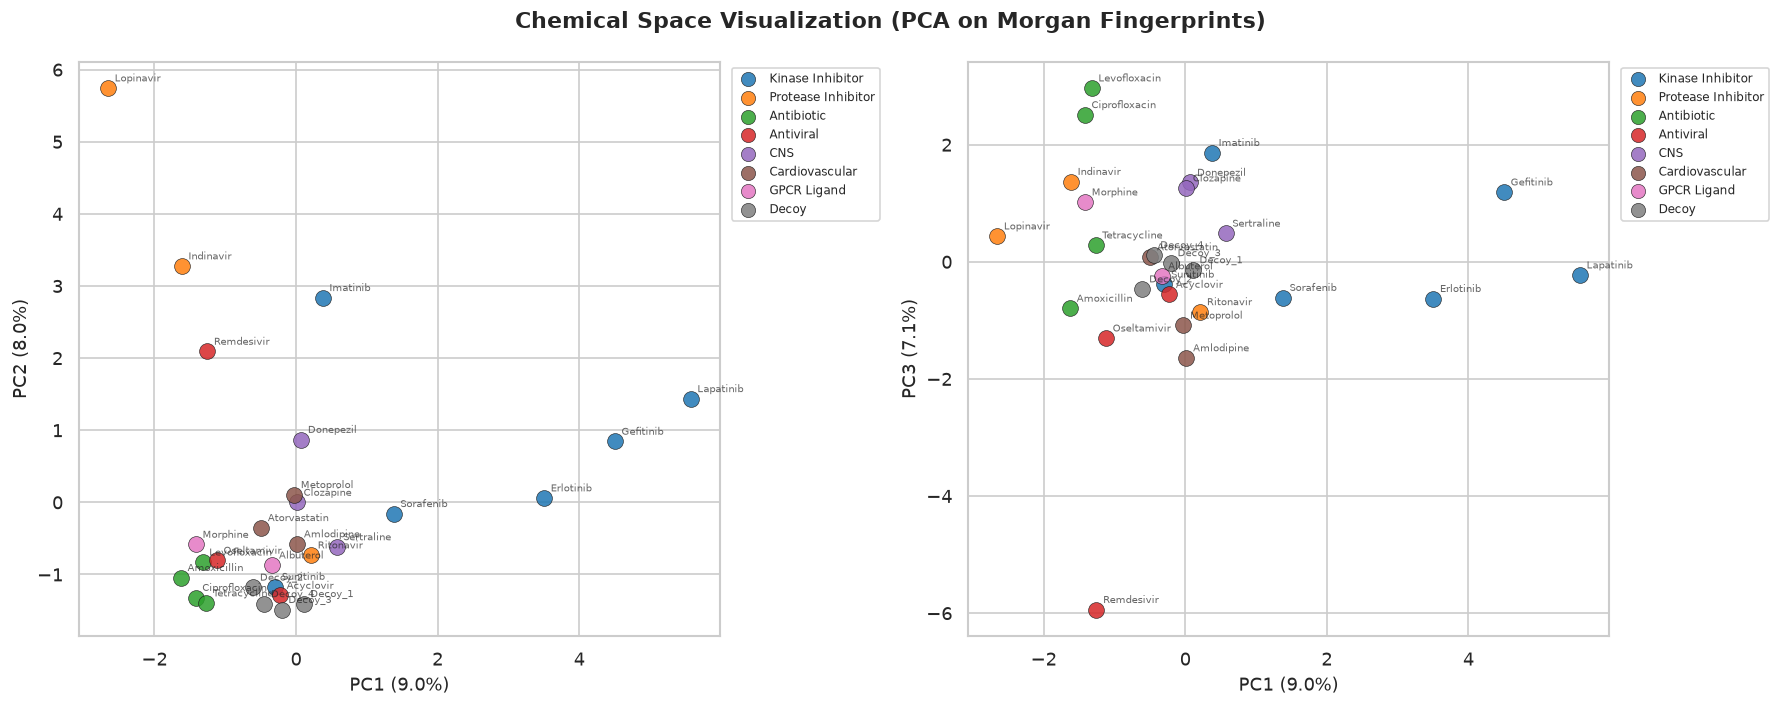


📊 Saved: chemical_space_pca.png
Variance explained: PC1=9.0%, PC2=8.0%, PC3=7.1%


In [7]:
# ============================================================
# CELL 6 — PCA-based chemical space visualization
# ============================================================

# Convert fingerprints to numpy array
fp_array = np.array([list(fp.ToBitString()) for fp in fps], dtype=int)

# PCA (no scaling needed for binary fingerprints — center only)
pca = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(fp_array)
explained = pca.explained_variance_ratio_ * 100

df['PC1'] = coords[:, 0]
df['PC2'] = coords[:, 1]
df['PC3'] = coords[:, 2]

# Color map by therapeutic class
classes = df['class'].unique()
palette = sns.color_palette('tab10', len(classes))
color_map = dict(zip(classes, palette))
df['color'] = df['class'].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Chemical Space Visualization (PCA on Morgan Fingerprints)', fontsize=13, fontweight='bold')

for ax, (xc, yc, xlab, ylab) in zip(
    axes,
    [('PC1','PC2', f'PC1 ({explained[0]:.1f}%)', f'PC2 ({explained[1]:.1f}%)'),
     ('PC1','PC3', f'PC1 ({explained[0]:.1f}%)', f'PC3 ({explained[2]:.1f}%)'),]
):
    for cls in classes:
        sub = df[df['class']==cls]
        ax.scatter(sub[xc], sub[yc],
                   c=[color_map[cls]],
                   s=90, alpha=0.85,
                   edgecolors='k', linewidth=0.4,
                   label=cls)
    for _, row in df.iterrows():
        ax.annotate(row['name'], (row[xc], row[yc]),
                    fontsize=6, alpha=0.7,
                    xytext=(4, 4), textcoords='offset points')
    ax.set_xlabel(xlab, fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.legend(fontsize=7, markerscale=0.9, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('chemical_space_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊 Saved: chemical_space_pca.png")
print(f"Variance explained: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, PC3={explained[2]:.1f}%")

---

## Section 7 — Scaffold Analysis: Bemis-Murcko Decomposition

The **Bemis-Murcko scaffold** framework, published in *Journal of Medicinal Chemistry* (1996), decomposes drug molecules into their core ring systems (scaffolds) by removing substituents and side chains. This approach is fundamental in:

- **Medicinal chemistry** — understanding SAR around a core scaffold  
- **Library design** — ensuring scaffold diversity  
- **IP analysis** — identifying patentable scaffold positions  

We extract scaffolds, count their frequency, and identify which molecules share the same core — a key step in series prioritization during lead optimization.


Unique Bemis-Murcko scaffolds identified: 24
Scaffold diversity index: 85.71%

Top scaffolds by frequency:
                                scaffold_smiles  count                        members
                                                     3      Decoy_1, Decoy_2, Decoy_3
                                       c1ccccc1      3 Metoprolol, Albuterol, Decoy_4
                                      C1=CCCCC1      1                    Oseltamivir
                 O=C(Cc1ccccc1)NC1C(=O)N2CCSC12      1                    Amoxicillin
                       c1ccc2nc(N3CCNCC3)cnc2c1      1                      Clozapine
                      c1ccc(Nc2ncnc3ccccc23)cc1      1                      Erlotinib
        c1ccc(Nc2ncnc3ccc(OCCCN4CCOCC4)cc23)cc1      1                      Gefitinib
c1ccc(COc2ccc(Nc3ncnc4ccc(-c5ccco5)cc34)cc2)cc1      1                      Lapatinib


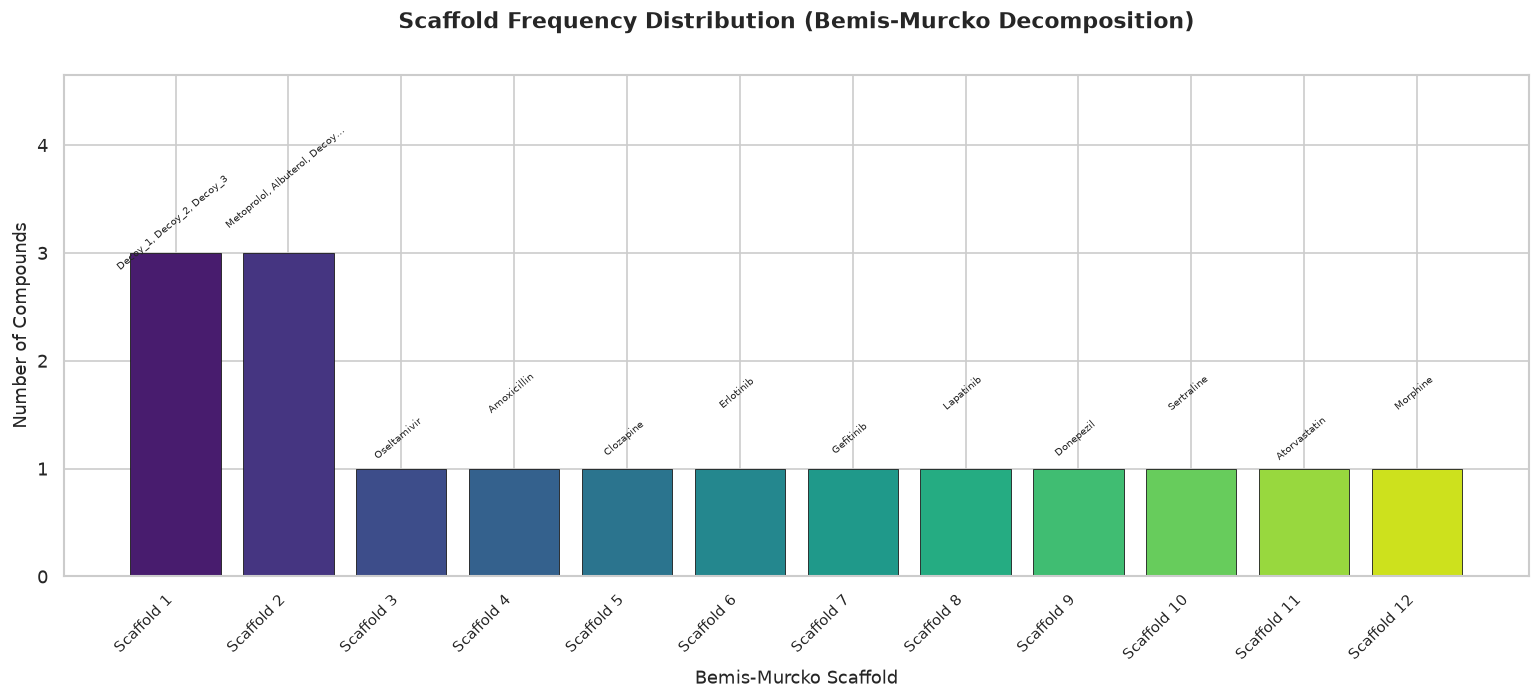

📊 Saved: scaffold_frequency.png


In [8]:
# ============================================================
# CELL 7 — Bemis-Murcko scaffold extraction and frequency plot
# ============================================================
def get_murcko_scaffold(mol):
    """Extract the Bemis-Murcko generic scaffold (atoms typed as carbons)."""
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        generic  = MurckoScaffold.MakeScaffoldGeneric(scaffold)
        return Chem.MolToSmiles(scaffold), Chem.MolToSmiles(generic)
    except:
        return None, None

df[['scaffold_smiles', 'generic_scaffold']] = df['mol'].apply(
    lambda m: pd.Series(get_murcko_scaffold(m))
)

# Scaffold frequency
scaffold_counts = (
    df.groupby('scaffold_smiles')
      .agg(count=('name','count'), members=('name', lambda x: ', '.join(x)))
      .sort_values('count', ascending=False)
      .reset_index()
)
print(f"Unique Bemis-Murcko scaffolds identified: {len(scaffold_counts)}")
print(f"Scaffold diversity index: {len(scaffold_counts)/len(df):.2%}\n")
print("Top scaffolds by frequency:")
print(scaffold_counts[['scaffold_smiles','count','members']].head(8).to_string(index=False))

# --- Scaffold frequency bar chart ---
top_scaffolds = scaffold_counts.head(12).copy()
top_scaffolds['label'] = [f"Scaffold {i+1}" for i in range(len(top_scaffolds))]

fig, ax = plt.subplots(figsize=(13, 6))          # ← wider figure gives bars more breathing room

bars = ax.bar(top_scaffolds['label'], top_scaffolds['count'],
              color=sns.color_palette('viridis', len(top_scaffolds)),
              edgecolor='k', linewidth=0.5)

ax.set_xlabel('Bemis-Murcko Scaffold', fontsize=11)
ax.set_ylabel('Number of Compounds', fontsize=11)
ax.set_title('Scaffold Frequency Distribution (Bemis-Murcko Decomposition)',
             fontsize=13, fontweight='bold', pad=28)   # ← pad makes headroom for annotations

ax.set_xticklabels(top_scaffolds['label'], rotation=45, ha='right', fontsize=9)

# ---- Annotate with member names — staggered height + rotated text ----
y_max = top_scaffolds['count'].max()
offsets = [0.08, 0.22]                            # two alternating offsets (fraction of y_max)

for i, (bar, (_, row)) in enumerate(zip(bars, top_scaffolds.iterrows())):
    label_text = row['members'][:28] + ('…' if len(row['members']) > 28 else '')
    y_pos = bar.get_height() + offsets[i % 2] * y_max   # ← alternate high / low
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        label_text,
        ha='center', va='bottom',
        fontsize=6,
        rotation=40,                              # ← angled so neighbours don't collide
        rotation_mode='anchor',
    )

# Push the y-axis ceiling up so the tallest annotation isn't clipped
ax.set_ylim(0, y_max * 1.55)

plt.tight_layout()
plt.savefig('scaffold_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: scaffold_frequency.png")

---

## Section 8 — Virtual Screening: Filtering a Compound Library

**Virtual screening** is the computational prioritization of compounds before biological testing. Here we simulate a typical **ligand-based virtual screening** workflow:

1. Define a **query compound** (the reference active)
2. Apply **drug-likeness filters** (Ro5 + Veber)
3. Rank remaining compounds by **Tanimoto similarity** to the query
4. Select **top hits** for further profiling

We use **Imatinib** (the BCR-ABL inhibitor Gleevec) as the query compound and search for similar kinase inhibitors from our library.


🔎 Query molecule: Imatinib
   SMILES: Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1...
   MW=493.62, cLogP=4.59, TPSA=86.28

🔬 After Ro5 + Veber filter: 21 / 28 compounds retained.

🎯 Virtual Screening Results (query: Imatinib)
   Tc threshold: ≥ 0.2
         name              class            target  Tc_to_query     MW  cLogP   TPSA
    Sorafenib   Kinase Inhibitor         RAF/VEGFR       0.1959 464.83  5.550  92.35
    Donepezil                CNS              AChE       0.1954 365.52  4.721  21.70
    Clozapine                CNS          D4/5-HT2       0.1899 262.74  2.035  32.26
    Gefitinib   Kinase Inhibitor              EGFR       0.1682 446.91  4.276  68.74
    Ritonavir Protease Inhibitor      HIV Protease       0.1579 345.51  5.228  45.23
 Levofloxacin         Antibiotic        DNA Gyrase       0.1373 361.37  1.544  75.01
   Metoprolol     Cardiovascular β1-adrenoreceptor       0.1348 267.37  1.613  50.72
 Atorvastatin     Cardiovascular HMG-CoA reductase     

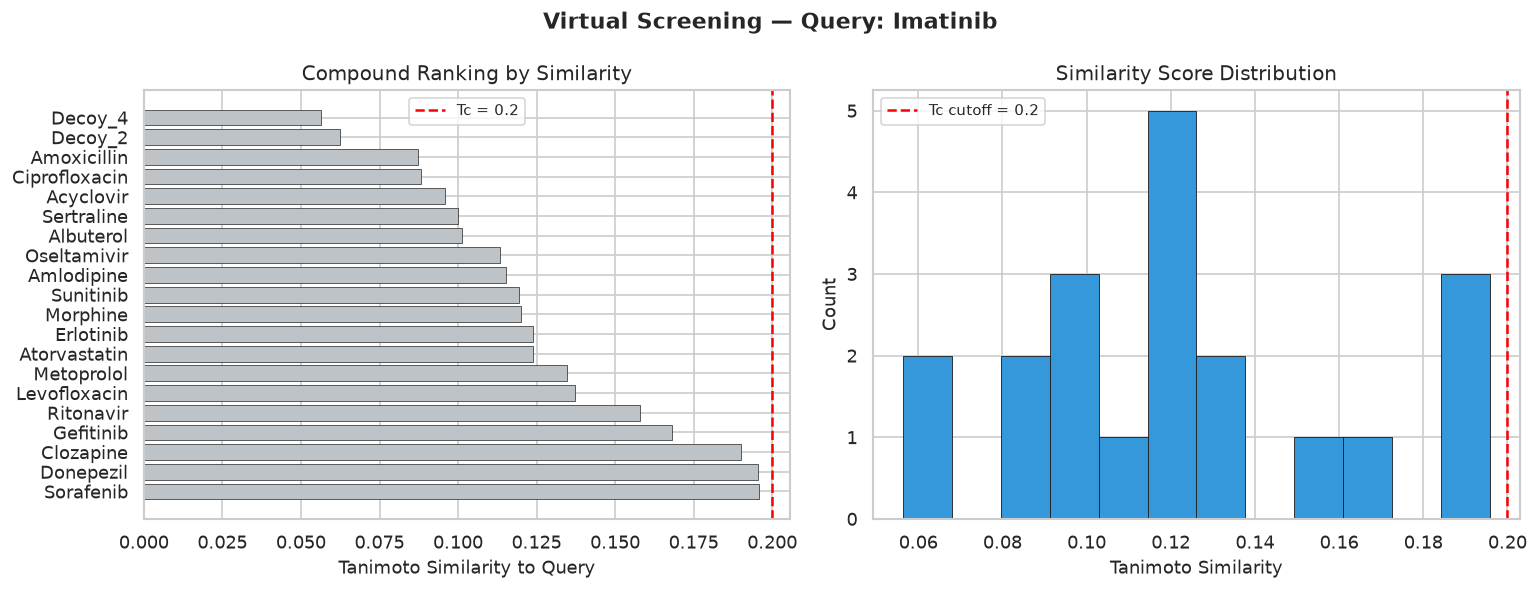

📊 Saved: virtual_screening_results.png


In [9]:
# ============================================================
# CELL 8 — Ligand-based virtual screening pipeline
# ============================================================

# Step 1: Define the query molecule
# To screen against a different reference compound, change ONLY the line below —
# every downstream step (pre-filtering, similarity ranking, plotting) updates automatically.
QUERY_NAME  = 'Imatinib'
query_row   = df[df['name'] == QUERY_NAME].iloc[0]
query_fp    = query_row['fp']
print(f"🔎 Query molecule: {QUERY_NAME}")
print(f"   SMILES: {query_row['canonical_smiles'][:80]}...")
print(f"   MW={query_row['MW']}, cLogP={query_row['cLogP']}, TPSA={query_row['TPSA']}")

# Step 2: Apply drug-likeness pre-filter
pre_filtered = df[df['Ro5_pass'] & df['Veber_pass']].copy()
print(f"\n🔬 After Ro5 + Veber filter: {len(pre_filtered)} / {len(df)} compounds retained.")

# Step 3: Compute similarity to query
pre_filtered['Tc_to_query'] = pre_filtered['fp'].apply(
    lambda fp: round(DataStructs.TanimotoSimilarity(query_fp, fp), 4)
)

# Step 4: Rank and apply hit threshold
TC_THRESHOLD = 0.20  # realistic for diverse library
hits = (
    pre_filtered[pre_filtered['name'] != QUERY_NAME]
    .sort_values('Tc_to_query', ascending=False)
)

print(f"\n🎯 Virtual Screening Results (query: {QUERY_NAME})")
print(f"   Tc threshold: ≥ {TC_THRESHOLD}")
print("="*65)

cols = ['name', 'class', 'target', 'Tc_to_query', 'MW', 'cLogP', 'TPSA']
print(hits[cols].to_string(index=False))

# Step 5: Plot similarity distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Virtual Screening — Query: {QUERY_NAME}', fontsize=13, fontweight='bold')

ax = axes[0]
tc_vals = hits['Tc_to_query'].values
ax.barh(hits['name'], tc_vals,
        color=[('#2ecc71' if t >= TC_THRESHOLD else '#bdc3c7') for t in tc_vals],
        edgecolor='k', linewidth=0.4)
ax.axvline(TC_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Tc = {TC_THRESHOLD}')
ax.set_xlabel('Tanimoto Similarity to Query', fontsize=11)
ax.set_title('Compound Ranking by Similarity', fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(tc_vals, bins=12, color='#3498db', edgecolor='k', linewidth=0.5)
ax.axvline(TC_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Tc cutoff = {TC_THRESHOLD}')
ax.set_xlabel('Tanimoto Similarity', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Similarity Score Distribution', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('virtual_screening_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: virtual_screening_results.png")

---

## Section 9 — PAINS Filtering (Pan-Assay Interference Compounds)

**PAINS** (Pan-Assay Interference Compounds) are structural motifs that frequently produce false positives in biochemical and cellular assays through mechanisms unrelated to specific target binding (e.g., redox cycling, fluorescence, covalent reactivity, metal chelation).

Filtering PAINS is now a standard requirement for publication in journals such as *J. Med. Chem.*, *ACS Med. Chem. Lett.*, and *Nat. Chem. Biol.*

RDKit implements the **Baell & Holloway (2010)** PAINS filters (480 structural alerts), derived from six AlphaScreen HTS campaigns run at Amgen and Abbott.

**A caution before you filter anything out:** PAINS alerts are statistical enrichment patterns from *those specific assay technologies*, not a universal chemical law. Capuzzi et al. (2017, *J. Chem. Inf. Model.*) showed that many PAINS-flagged compounds are genuinely active in orthogonal, non-AlphaScreen assays — so a PAINS hit is a prompt for closer scrutiny (orthogonal assay, dose-response, structural rationale), not an automatic disqualification. This notebook follows the recommended practice below: **flag, don't silently discard.**


 PAINS Filter Results (Baell & Holloway 2010)
 Total compounds screened : 28
 PAINS-flagged (removed)  : 2  (7%)
 Clean compounds retained : 26

⚠️  Flagged PAINS compounds:
   • Lopinavir            → alerts: ['anil_no_alk(40)']
   • Decoy_4              → alerts: ['catechol_A(92)']


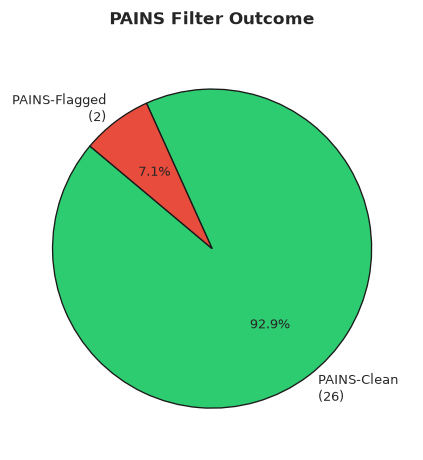

📊 Saved: pains_filter.png


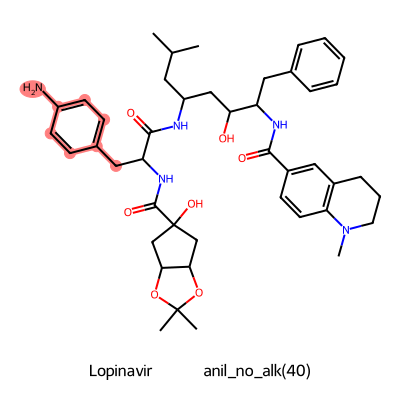

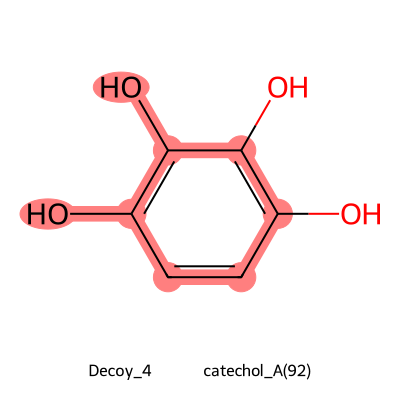


📊 Saved 2 PAINS-highlighted structure SVG(s): pains_highlight_Lopinavir.svg, pains_highlight_Decoy_4.svg


In [10]:
# ============================================================
# CELL 9 — PAINS filtering using RDKit FilterCatalog
# ============================================================

from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# Initialize PAINS filter catalog (Baell & Holloway 2010 — all three sets A, B, C)
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_A)
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_B)
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_C)
catalog = FilterCatalog(params)

def check_pains(mol):
    """Returns (is_PAINS, list_of_alerts) for a molecule."""
    if mol is None:
        return True, ['invalid']
    entries = catalog.GetMatches(mol)
    alerts  = [e.GetDescription() for e in entries]
    return len(alerts) > 0, alerts

pains_results = df['mol'].apply(check_pains)
df['is_PAINS']    = pains_results.apply(lambda x: x[0])
df['PAINS_alerts'] = pains_results.apply(lambda x: x[1])
df['n_PAINS']      = df['PAINS_alerts'].apply(len)

clean_df = df[~df['is_PAINS']]
pains_df = df[df['is_PAINS']]

print("=" * 50)
print(f" PAINS Filter Results (Baell & Holloway 2010)")
print("=" * 50)
print(f" Total compounds screened : {len(df)}")
print(f" PAINS-flagged (removed)  : {df['is_PAINS'].sum()}  ({df['is_PAINS'].mean():.0%})")
print(f" Clean compounds retained : {len(clean_df)}")
print("=" * 50)

if len(pains_df) > 0:
    print("\n⚠️  Flagged PAINS compounds:")
    for _, row in pains_df.iterrows():
        print(f"   • {row['name']:20s} → alerts: {row['PAINS_alerts']}")
else:
    print("\n✅ No PAINS alerts detected in this dataset.")

# Pie chart
fig, ax = plt.subplots(figsize=(4, 4))
vals   = [len(clean_df), df['is_PAINS'].sum()]
labels = [f'PAINS-Clean\n({len(clean_df)})', f'PAINS-Flagged\n({df["is_PAINS"].sum()})']
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    vals, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='k', linewidth=0.8),
    textprops=dict(fontsize=8)
)
ax.set_title('PAINS Filter Outcome', fontsize=10, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('pains_filter.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: pains_filter.png")

# ------------------------------------------------------------
# Visualize the flagged PAINS substructure(s) on each compound
# (addresses reviewer request for a visual, not just a text alert)
# ------------------------------------------------------------
def draw_pains_highlight(mol, alerts, legend, filename):
    """Draw a 2D structure with the matched PAINS substructure atoms/bonds highlighted in red."""
    highlight_atoms = set()
    highlight_bonds = set()
    for entry in catalog.GetMatches(mol):
        for fm in entry.GetFilterMatches(mol):
            atom_idxs = [pair[1] for pair in fm.atomPairs]
            highlight_atoms.update(atom_idxs)
    atom_set = set(highlight_atoms)
    for bond in mol.GetBonds():
        if bond.GetBeginAtomIdx() in atom_set and bond.GetEndAtomIdx() in atom_set:
            highlight_bonds.add(bond.GetIdx())

    drawer = rdMolDraw2D.MolDraw2DCairo(400, 400) if False else rdMolDraw2D.MolDraw2DSVG(400, 400)
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=list(highlight_atoms),
        highlightBonds=list(highlight_bonds),
        legend=legend,
    )
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    with open(filename, 'w') as f:
        f.write(svg)
    return svg

if len(pains_df) > 0:
    from IPython.display import SVG
    svgs = []
    for _, row in pains_df.iterrows():
        fname = f"pains_highlight_{row['name']}.svg"
        legend = f"{row['name']} — {', '.join(row['PAINS_alerts'])}"
        svg = draw_pains_highlight(row['mol'], row['PAINS_alerts'], legend, fname)
        svgs.append((row['name'], fname))
        display(SVG(svg))
    print(f"\n📊 Saved {len(svgs)} PAINS-highlighted structure SVG(s): "
          + ", ".join(f for _, f in svgs))


---

## Section 10 — 2D Molecular Structure Visualization

Clear 2D structural drawings are essential for both scientific publications and medicinal chemistry review. RDKit's `Draw` module generates publication-quality 2D depictions with automatic coordinate generation using the **RDKit 2D coordinate engine**.

Here we generate a grid image of the kinase inhibitors in our dataset, with key properties annotated below each structure — a format commonly used in medicinal chemistry tables and SAR papers.


📊 2D grid of 6 kinase inhibitors saved: kinase_inhibitors_2d.svg


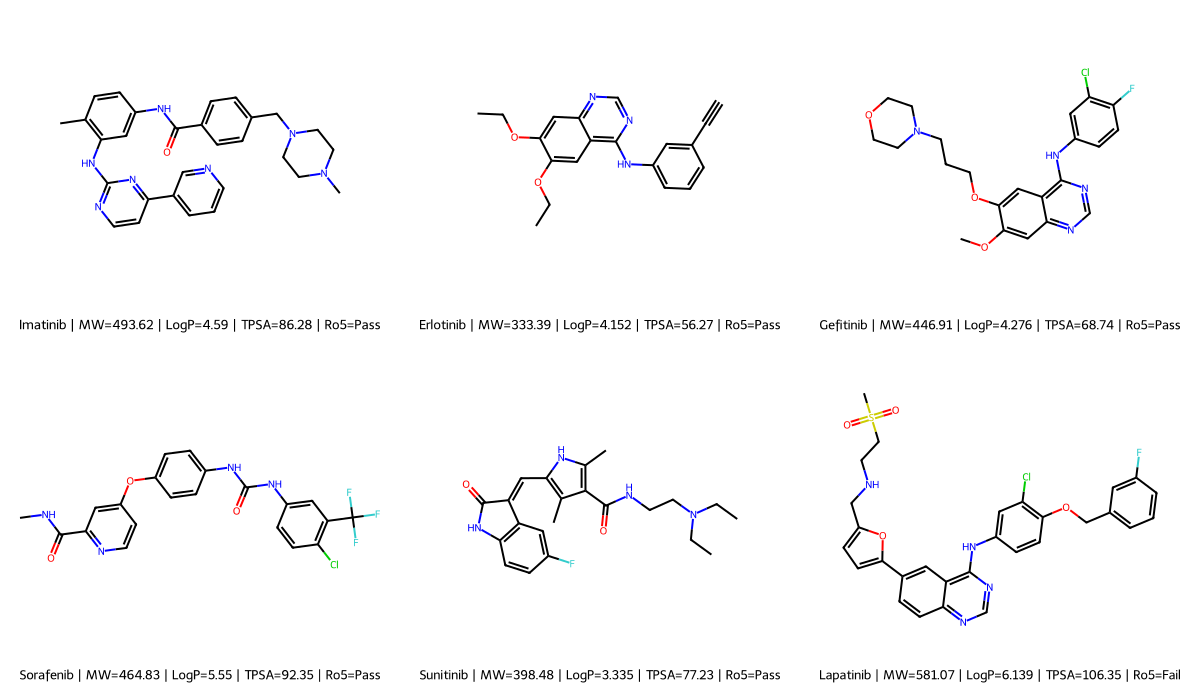

In [11]:
# ============================================================
# CELL 10 — 2D structure grid visualization
# ============================================================
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

# Select kinase inhibitors for visualization (kinase is used in this example)
ki_df  = df[df['class'] == 'Kinase Inhibitor'].copy()
mols   = ki_df['mol'].tolist()
labels = [
    f"{row['name']} | MW={row['MW']} | LogP={row['cLogP']} | TPSA={row['TPSA']} | Ro5={'Pass' if row['Ro5_pass'] else 'Fail'}"
    for _, row in ki_df.iterrows()
]

# ── Draw directly with rdMolDraw2D ──
n_rows  = (len(mols) + 2) // 3
w, h    = 400, 350
canvas  = rdMolDraw2D.MolDraw2DSVG(3 * w, n_rows * h, w, h)
canvas.DrawMolecules(mols, legends=labels)
canvas.FinishDrawing()
svg_str = canvas.GetDrawingText()          

# Save
with open('kinase_inhibitors_2d.svg', 'w', encoding='utf-8') as f:
    f.write(svg_str)
print(f"📊 2D grid of {len(mols)} kinase inhibitors saved: kinase_inhibitors_2d.svg")

# Render inline
display(SVG(svg_str))

---

## Section 11 — Descriptor Correlation & Property Distribution Analysis

Understanding how molecular properties correlate with each other — and how they distribute across a chemical library — is a key step in **ADMET-aware library design** and **chemical space characterization**. For example:

- MW and HBA often co-increase (larger molecules have more acceptors)
- High LogP and low TPSA both favor membrane permeability but may increase toxicity
- Fsp3 (fraction of sp3 carbons) is inversely correlated with aromaticity and clinical attrition

We generate a **pairplot** and a **correlation heatmap** to summarize inter-property relationships.


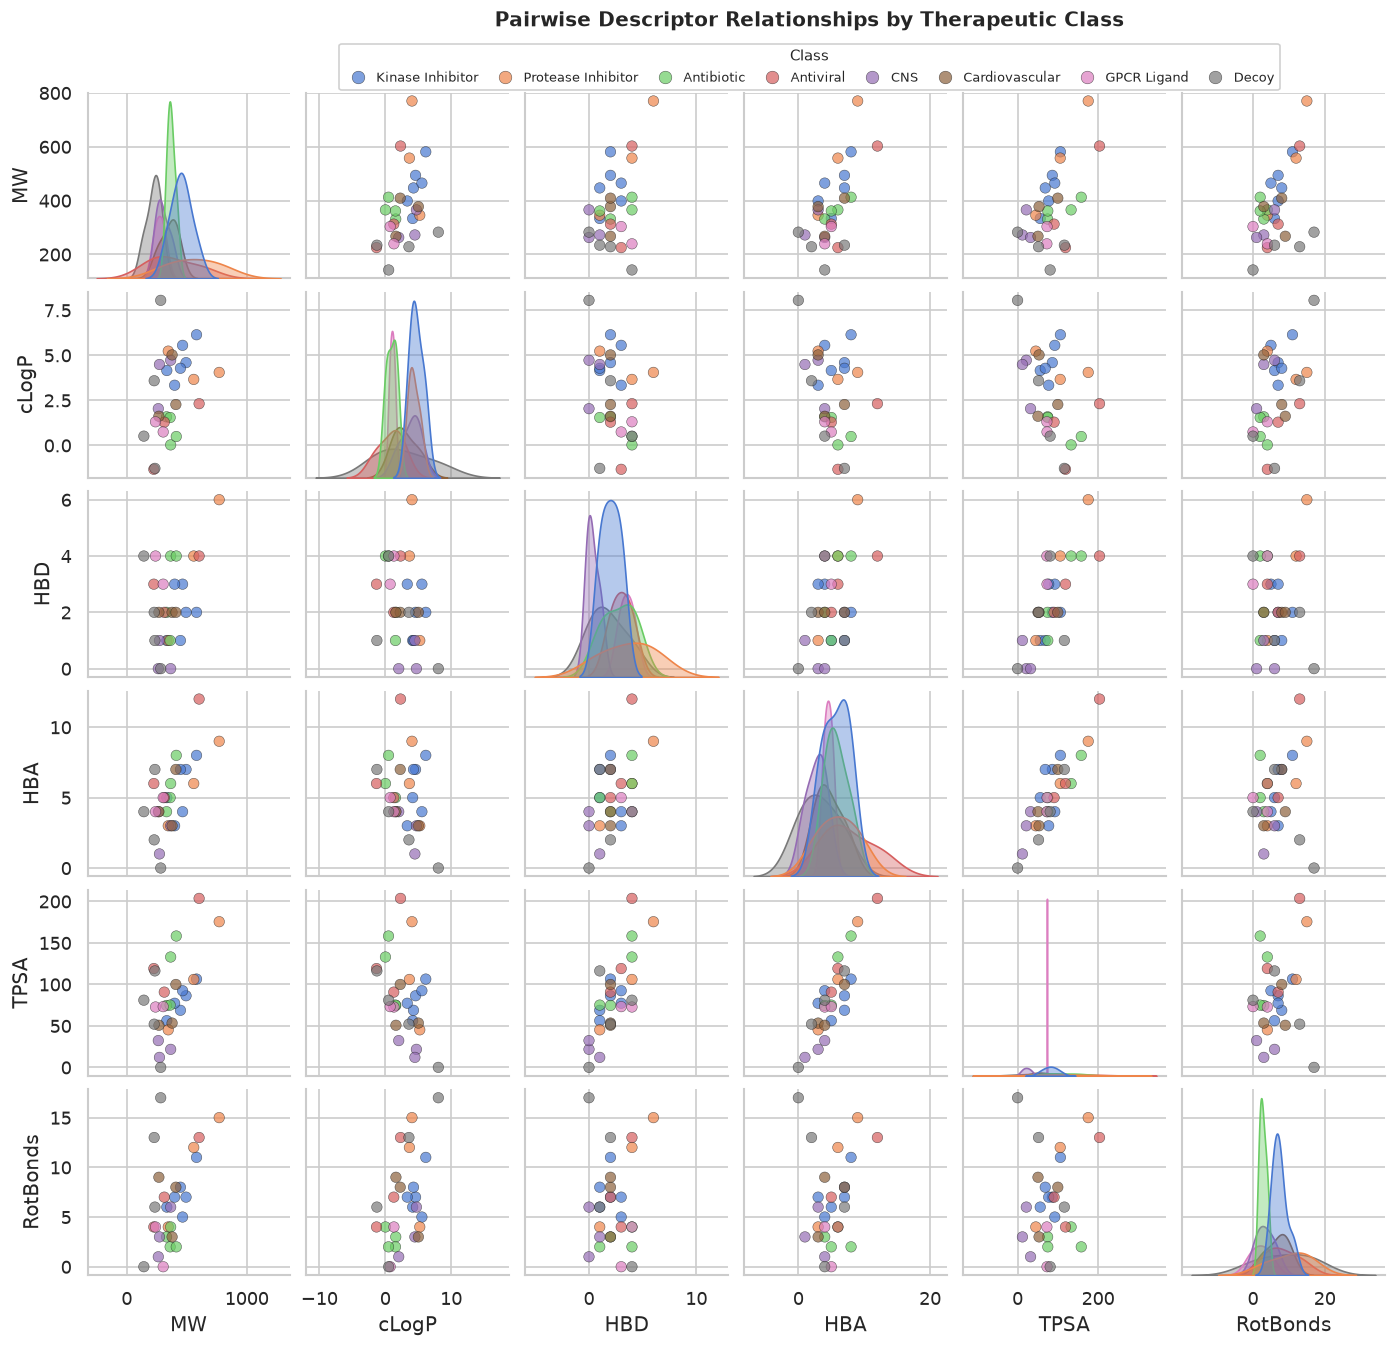

📊 Saved: descriptor_pairplot.png


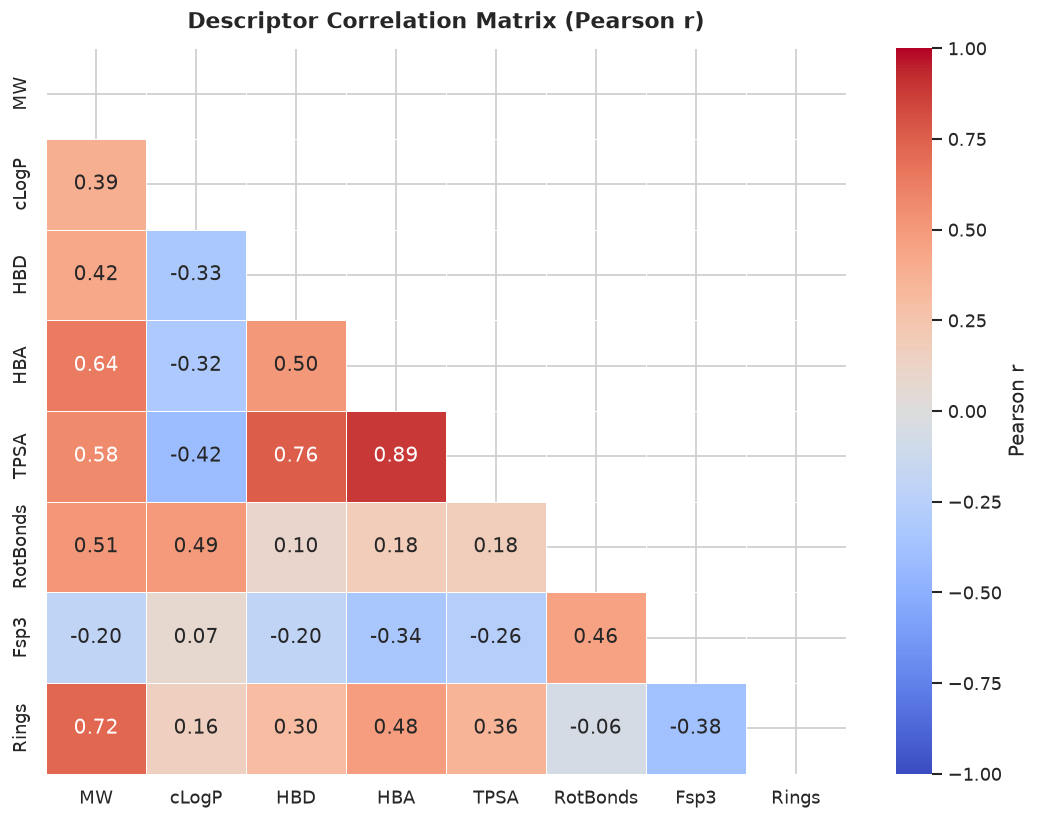

📊 Saved: descriptor_correlation.png


In [12]:
# ============================================================
# CELL 11 — Descriptor distribution and correlation analysis
# ============================================================
prop_cols = ['MW', 'cLogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Fsp3', 'Rings']
plot_df   = df[prop_cols + ['class']].copy()

# ---- Pairplot (colored by class) ----
g = sns.pairplot(
    plot_df,
    hue='class',
    vars=prop_cols[:6],
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'k', 'linewidth': 0.3},
    diag_kws={'fill': True, 'alpha': 0.4},
    height=1.8, aspect=1.1,
    # NO legend= kwarg — we remove it manually below
)

# ---- Remove the auto-generated legend seaborn placed inside the grid ----
if g.legend is not None:
    g.legend.remove()

g.figure.suptitle('Pairwise Descriptor Relationships by Therapeutic Class',
                  y=1.04, fontsize=12, fontweight='bold')

# ---- Rebuild legend manually as a clean horizontal bar above the grid ----
handles, labels = [], []
for class_name, artist in g._legend_data.items():
    handles.append(artist)
    labels.append(class_name)

g.figure.legend(
    handles=handles,
    labels=labels,
    title='Class',
    fontsize=8,
    title_fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),   # sits between grid and suptitle
    ncol=len(handles),             # single horizontal row — no overlap
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    markerscale=1.2,
    columnspacing=1.0,
    handletextpad=0.4,
)

plt.savefig('descriptor_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 Saved: descriptor_pairplot.png")

# ---- Correlation heatmap ----
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[prop_cols].corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, ax=ax, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    center=0, linewidths=0.5,
    cbar_kws={'label': 'Pearson r', 'shrink': 1}
)
ax.set_title('Descriptor Correlation Matrix (Pearson r)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('descriptor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: descriptor_correlation.png")

---

## Section 12 — Radar / Spider Chart for Drug Profile Comparison

**Radar charts** (spider plots) allow intuitive visual comparison of multiple molecular properties simultaneously. They are widely used in medicinal chemistry and drug discovery review papers to compare ADMET profiles of lead compounds.

Here we compare three kinase inhibitors — Imatinib, Erlotinib, and Gefitinib — across six normalized physicochemical dimensions, overlaid on the **ideal drug-like property space**.


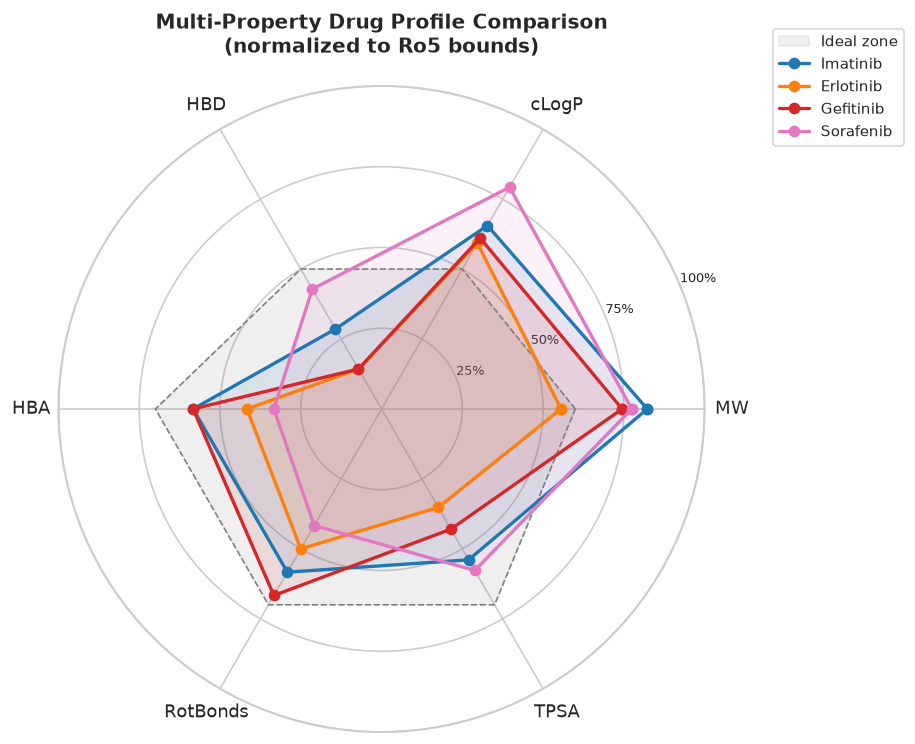

📊 Saved: radar_drug_profile.png


In [13]:
# ============================================================
# CELL 12 — Radar chart for multi-property drug profile comparison
# ============================================================

import matplotlib.patches as mpatches

# Normalize each property to [0, 1] against Ro5 upper bounds
# Bounds: MW(500), LogP(5), HBD(5), HBA(10), RotBonds(10), TPSA(140)
BOUNDS = {'MW': 600, 'cLogP': 7, 'HBD': 7, 'HBA': 12, 'RotBonds': 12, 'TPSA': 160}
IDEAL  = {'MW': 0.6, 'cLogP': 0.5, 'HBD': 0.5, 'HBA': 0.7, 'RotBonds': 0.7, 'TPSA': 0.7}  # Ro5-like ideal

COMPARE = ['Imatinib', 'Erlotinib', 'Gefitinib', 'Sorafenib']
props   = list(BOUNDS.keys())
N       = len(props)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors  = plt.cm.tab10(np.linspace(0, 0.6, len(COMPARE)))

# Draw ideal zone (shaded)
ideal_vals = [IDEAL[p] for p in props] + [IDEAL[props[0]]]
ax.fill(angles, ideal_vals, alpha=0.12, color='gray', label='Ideal zone')
ax.plot(angles, ideal_vals, color='gray', linewidth=1, linestyle='--')

for mol_name, color in zip(COMPARE, colors):
    row = df[df['name'] == mol_name].iloc[0]
    vals = [min(row[p] / BOUNDS[p], 1.0) for p in props]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=mol_name, markersize=6)
    ax.fill(angles, vals, alpha=0.10, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(props, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('Multi-Property Drug Profile Comparison\n(normalized to Ro5 bounds)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig('radar_drug_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: radar_drug_profile.png")

---

## Section 13 — Maximum Common Substructure (MCS) Analysis

The **Maximum Common Substructure (MCS)** algorithm identifies the largest shared scaffold between two or more molecules. This is essential for:

- **R-group decomposition** in SAR tables  
- **Scaffold alignment** in molecular overlays  
- **Bioisostere identification** during lead optimization  

Here we compute the MCS between the EGFR inhibitors (Erlotinib and Gefitinib), which are known to share a 4-anilinoquinazoline core scaffold.


In [14]:
# ============================================================
# CELL 13 — Maximum Common Substructure (MCS) detection
# ============================================================
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdMolDraw2D
import xml.etree.ElementTree as ET
from io import BytesIO
import numpy as np

def compute_mcs(mol_list, timeout=10):
    """Compute the MCS for a list of RDKit Mol objects."""
    result = rdFMCS.FindMCS(
        mol_list,
        atomCompare=rdFMCS.AtomCompare.CompareElements,
        bondCompare=rdFMCS.BondCompare.CompareOrderExact,
        completeRingsOnly=True,
        timeout=timeout
    )
    return result

# Compare EGFR inhibitors
egfr_names = ['Erlotinib', 'Gefitinib', 'Lapatinib']
egfr_mols  = [df[df['name']==n]['mol'].values[0] for n in egfr_names]
mcs_result = compute_mcs(egfr_mols)
mcs_mol    = Chem.MolFromSmarts(mcs_result.smartsString)

print(f"MCS Analysis: {', '.join(egfr_names)}")
print(f"   MCS SMARTS  : {mcs_result.smartsString}")
print(f"   Num atoms   : {mcs_result.numAtoms}")
print(f"   Num bonds   : {mcs_result.numBonds}")
print(f"   Timed out?  : {mcs_result.canceled}")

# ── Helper: draw one molecule to SVG string ───────
def mol_to_svg(mol, size=(350, 280), highlight_atoms=(), highlight_color=(0.2, 0.8, 0.4)):
    w, h = size
    drawer = rdMolDraw2D.MolDraw2DSVG(w, h)
    drawer.drawOptions().addStereoAnnotation = False
    rdMolDraw2D.PrepareMolForDrawing(mol)

    hit_atoms = list(highlight_atoms)
    hit_bonds = []
    if hit_atoms:
        # highlight bonds whose both ends are in the MCS match
        for bond in mol.GetBonds():
            if bond.GetBeginAtomIdx() in hit_atoms and bond.GetEndAtomIdx() in hit_atoms:
                hit_bonds.append(bond.GetIdx())

    atom_cols  = {a: highlight_color for a in hit_atoms}
    bond_cols  = {b: highlight_color for b in hit_bonds}

    drawer.DrawMolecule(
        mol,
        highlightAtoms=hit_atoms,
        highlightBonds=hit_bonds,
        highlightAtomColors=atom_cols,
        highlightBondColors=bond_cols,
    )
    drawer.FinishDrawing()
    return drawer.GetDrawingText()          # plain str

# ── Render each molecule and collect SVG strings ─────────────
svg_panels = []
for mol, name in zip(egfr_mols, egfr_names):
    match = mol.GetSubstructMatch(mcs_mol)
    svg   = mol_to_svg(mol, size=(350, 280), highlight_atoms=match)
    svg_panels.append((svg, name))

# ── Display with matplotlib using SVG ────
# We use matplotlib + SVG display via IPython
from IPython.display import SVG as ISVG, display, HTML

# Build a single-row HTML table of SVGs for clean inline display
cells = ""
for svg, name in svg_panels:
    cells += f"""
    <td style="text-align:center; padding:6px; font-family:sans-serif;">
        <b>{name}</b><br>{svg}
    </td>"""

html_out = f"""
<h3 style="font-family:sans-serif; text-align:center;">
    MCS Highlighted in EGFR Inhibitors
    <span style="color:#2c2; font-weight:normal;"> (green = shared core)</span>
</h3>
<table style="margin:auto;"><tr>{cells}</tr></table>
"""
display(HTML(html_out))

# ── Also save individual SVGs ─────────────────────────────────
for svg, name in svg_panels:
    fname = f"mcs_{name.lower()}.svg"
    with open(fname, 'w', encoding='utf-8') as f:
        f.write(svg)

print(f"📊 Saved {len(svg_panels)} SVG files: " +
      ", ".join(f"mcs_{n.lower()}.svg" for _, n in svg_panels))

MCS Analysis: Erlotinib, Gefitinib, Lapatinib
   MCS SMARTS  : [#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#7]-&!@[#6]1:&@[#7]:&@[#6]:&@[#7]:&@[#6]2:&@[#6]:&@1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2
   Num atoms   : 17
   Num bonds   : 19
   Timed out?  : False


📊 Saved 3 SVG files: mcs_erlotinib.svg, mcs_gefitinib.svg, mcs_lapatinib.svg


---

## Section 14 — Final Summary Report

We compile all key results into a **structured summary table** — the type of data table typically found in the Supporting Information of a cheminformatics publication.


In [15]:
# ============================================================
# CELL 14 — Final consolidated summary report
# ============================================================

report_cols = [
    'name', 'class', 'target',
    'MW', 'cLogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Fsp3',
    'Ro5_pass', 'Veber_pass', 'LeadLike_pass', 'is_PAINS'
]

report = df[report_cols].copy()
report.columns = [
    'Compound', 'Class', 'Target',
    'MW', 'cLogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Fsp3',
    'Ro5', 'Veber', 'LeadLike', 'PAINS'
]

# Map booleans to readable symbols
for col in ['Ro5', 'Veber', 'LeadLike']:
    report[col] = report[col].map({True: '✓ Pass', False: '✗ Fail'})
report['PAINS'] = report['PAINS'].map({True: '⚠ Alert', False: '✓ Clean'})

print("📋 Full Compound Summary Report")
print("="*100)
with pd.option_context('display.max_columns', None, 'display.width', 180):
    print(report.to_string(index=False))

# Save to CSV
report.to_csv('final_summary_report.csv', index=False)
print("\n✅ Report saved to: final_summary_report.csv")

# --- High-level stats ---
print("\n" + "="*60)
print("📊 PIPELINE SUMMARY STATISTICS")
print("="*60)
print(f"  Total compounds analyzed         : {len(df)}")
print(f"  Ro5-compliant                    : {df['Ro5_pass'].sum()} ({df['Ro5_pass'].mean():.0%})")
print(f"  Veber-compliant                  : {df['Veber_pass'].sum()} ({df['Veber_pass'].mean():.0%})")
print(f"  Lead-like                        : {df['LeadLike_pass'].sum()} ({df['LeadLike_pass'].mean():.0%})")
print(f"  PAINS-free (clean)               : {(~df['is_PAINS']).sum()} ({(~df['is_PAINS']).mean():.0%})")
print(f"  Unique Bemis-Murcko scaffolds    : {df['scaffold_smiles'].nunique()}")
print(f"  Scaffold diversity index         : {df['scaffold_smiles'].nunique()/len(df):.2%}")
print(f"  Mean MW                          : {df['MW'].mean():.1f} Da")
print(f"  Mean cLogP                       : {df['cLogP'].mean():.2f}")
print(f"  Mean TPSA                        : {df['TPSA'].mean():.1f} Å²")
print("="*60)

📋 Full Compound Summary Report
     Compound              Class            Target     MW  cLogP  HBD  HBA   TPSA  RotBonds  Fsp3    Ro5  Veber LeadLike   PAINS
     Imatinib   Kinase Inhibitor           BCR-ABL 493.62  4.590  2.0  7.0  86.28       7.0 0.241 ✓ Pass ✓ Pass   ✗ Fail ✓ Clean
    Erlotinib   Kinase Inhibitor              EGFR 333.39  4.152  1.0  5.0  56.27       6.0 0.200 ✓ Pass ✓ Pass   ✓ Pass ✓ Clean
    Gefitinib   Kinase Inhibitor              EGFR 446.91  4.276  1.0  7.0  68.74       8.0 0.364 ✓ Pass ✓ Pass   ✗ Fail ✓ Clean
    Sorafenib   Kinase Inhibitor         RAF/VEGFR 464.83  5.550  3.0  4.0  92.35       5.0 0.095 ✓ Pass ✓ Pass   ✗ Fail ✓ Clean
    Sunitinib   Kinase Inhibitor             VEGFR 398.48  3.335  3.0  3.0  77.23       7.0 0.364 ✓ Pass ✓ Pass   ✓ Pass ✓ Clean
    Lapatinib   Kinase Inhibitor         HER2/EGFR 581.07  6.139  2.0  8.0 106.35      11.0 0.172 ✗ Fail ✗ Fail   ✗ Fail ✓ Clean
    Ritonavir Protease Inhibitor      HIV Protease 345.51  5.228  

---

## Section 15 — Files Generated by This Notebook

All output files are saved in your current working directory (`C:\Users\HP\` or wherever you ran this notebook):

| File | Description |
|---|---|
| `descriptors_table.csv` | Full physicochemical descriptor table |
| `final_summary_report.csv` | Complete compound report with filter outcomes |
| `drug_likeness_filters.png` | Ro5 / Veber scatter and bar charts |
| `tanimoto_heatmap.png` | Pairwise Tanimoto similarity heatmap |
| `chemical_space_pca.png` | PCA-based chemical space map |
| `scaffold_frequency.png` | Bemis-Murcko scaffold frequency bar chart |
| `virtual_screening_results.png` | Ligand-based virtual screening ranking |
| `pains_filter.png` | PAINS filter outcome pie chart |
| `kinase_inhibitors_2d.png` | 2D structure grid of kinase inhibitors |
| `descriptor_pairplot.png` | Pairwise descriptor scatterplot matrix |
| `descriptor_correlation.png` | Pearson correlation heatmap |
| `radar_drug_profile.png` | Multi-property radar chart |
| `mcs_egfr_inhibitors.png` | MCS-highlighted EGFR inhibitor comparison |

---

## References

1. Lipinski, C.A. *et al.* (1997). *Adv. Drug Deliv. Rev.*, 23, 3–25. [Rule of Five]
2. Veber, D.F. *et al.* (2002). *J. Med. Chem.*, 45, 2615–2623. [Veber's rules]
3. Bemis, G.W. & Murcko, M.A. (1996). *J. Med. Chem.*, 39, 2887–2893. [Scaffold decomposition]
4. Baell, J.B. & Holloway, G.A. (2010). *J. Med. Chem.*, 53, 2719–2740. [PAINS filters]
5. Morgan, H.L. (1965). *J. Chem. Doc.*, 5, 107–113. [Morgan algorithm]
6. Landrum, G. *et al.* RDKit: Open-source cheminformatics. https://www.rdkit.org
7. Rogers, D. & Hahn, M. (2010). *J. Chem. Inf. Model.*, 50, 742–754. [ECFP fingerprints]

---

> 💡 **Tip for publication:** This notebook can be exported to PDF via `File → Export Notebook As → PDF` (requires TeX), or to HTML via `jupyter nbconvert --to html cheminformatics_drug_discovery.ipynb`.
